In [13]:
from rdkit import Chem
import pandas as pd
import json

The output files of the QFP program are given in the following format:

"example_input_{id}.json" provides a **list** of conformers. For each conformer, the xyz coordinates + bunch of properties

In [30]:
PATH = "../data/QuantumFP/QFP_input.json"
with open(PATH, "r") as f:
    data = json.load(f)

In [35]:
df = pd.DataFrame(data["inputs"])
df = df.drop(columns=["id"])
print(df)

                                                 smiles
0     O=[C:1]1[N:2]([H:13])[c:3]2[c:4]([H:14])[c:5](...
1     Cl[c:1]1[c:2]([H:9])[c:3]([H:10])[c:4]([C:5](=...
2     C1([H:31])([H:32])[O:1][C:2]1([C:3]([N:4]([C:5...
3     C([c:1]1[c:2]([H:12])[c:3]([H:13])[c:4]([H:14]...
4     C([C:1]([C:2]1([H:17])[C:3]([H:18])([H:19])[C:...
...                                                 ...
8840  C([c:1]1[c:2]([H:19])[c:3]([H:20])[c:4]([N:7](...
8841  O([c:1]1[c:2]2[c:28]([c:29]([H:53])[c:30]([H:5...
8842  c1([O:10][H:24])[c:1]([H:11])[c:2]([C:9]([H:21...
8843  C([O:1][c:2]1[c:3]([H:36])[c:4]([H:37])[c:5]([...
8844  C([C:1](=[O:2])[C:3]([C:4]([c:5]1[c:6]([H:29])...

[8845 rows x 1 columns]


In [36]:
mols = [Chem.MolFromSmiles(smiles) for smiles in df["smiles"]]
df['num_heavy_atoms'] = pd.DataFrame(
    [mol.GetNumHeavyAtoms() for mol in mols]
)

In [37]:
print(df)

                                                 smiles  num_heavy_atoms
0     O=[C:1]1[N:2]([H:13])[c:3]2[c:4]([H:14])[c:5](...               13
1     Cl[c:1]1[c:2]([H:9])[c:3]([H:10])[c:4]([C:5](=...                9
2     C1([H:31])([H:32])[O:1][C:2]1([C:3]([N:4]([C:5...               31
3     C([c:1]1[c:2]([H:12])[c:3]([H:13])[c:4]([H:14]...                9
4     C([C:1]([C:2]1([H:17])[C:3]([H:18])([H:19])[C:...               12
...                                                 ...              ...
8840  C([c:1]1[c:2]([H:19])[c:3]([H:20])[c:4]([N:7](...               19
8841  O([c:1]1[c:2]2[c:28]([c:29]([H:53])[c:30]([H:5...               32
8842  c1([O:10][H:24])[c:1]([H:11])[c:2]([C:9]([H:21...               11
8843  C([O:1][c:2]1[c:3]([H:36])[c:4]([H:37])[c:5]([...               33
8844  C([C:1](=[O:2])[C:3]([C:4]([c:5]1[c:6]([H:29])...               23

[8845 rows x 2 columns]


(16.430977953646128, 8.79344298521499)

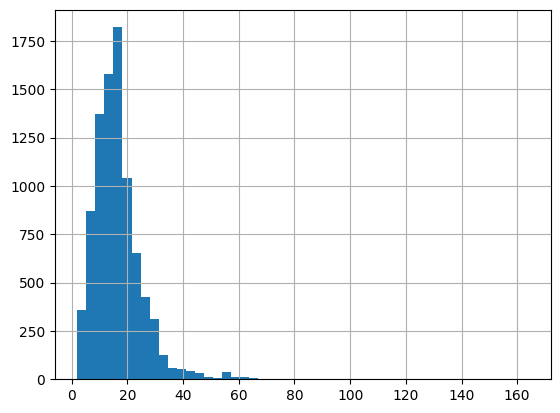

In [38]:
df["num_heavy_atoms"].hist(bins=50)
(df["num_heavy_atoms"].mean(), df["num_heavy_atoms"].std())